In [116]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [117]:
class eqState(TypedDict):
    a: int
    b: int
    c: int

    discriminant: float
    root1: float
    root2: float
    result :str

In [118]:
graph = StateGraph(eqState)

In [119]:
def calculate_discriminant(state: eqState):
    a= state['a']
    b= state['b']
    c= state['c']

    discriminant = b**2-4*a*c

    return {'discriminant':discriminant}

In [120]:
def real_equal_roots(state: eqState):
    a= state['a']
    b= state['b']
    c= state['c']
    discriminant = state['discriminant']

    root = -b/(2*a)
    result = f'the quadratic has 2 equal roots {root}'
    return {'root1':root,'root2':root,'result':result}

In [121]:
def real_distinct_roots(state: eqState):
    a= state['a']
    b= state['b']
    c= state['c']
    discriminant = state['discriminant']

    root1 = (-b+discriminant**0.5)/(2*a)
    root2 = (-b-discriminant**0.5)/(2*a)
    result = f'the quadratic has 2 distinct roots {root1},{root2}'
    return {'root1':root1,'root2':root2,'result':result}

In [122]:
def imaginary_roots(state: eqState):
    result = f"the quadratic has non real roots i mean imaginary roots"
    return {'result':result}

In [123]:
def route_discriminant(state: eqState)->Literal['real_equal_roots','real_distinct_roots','imaginary_roots']:
    discriminant = state['discriminant']
    
    if discriminant == 0:
        return 'real_equal_roots'
    elif discriminant > 0:
        return 'real_distinct_roots'
    else:
        return 'imaginary_roots'

In [124]:
graph.add_node('calculate_discriminant',calculate_discriminant)
graph.add_node('real_equal_roots',real_equal_roots)
graph.add_node('real_distinct_roots',real_distinct_roots)
graph.add_node('imaginary_roots',imaginary_roots)

graph.add_edge(START,'calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant',route_discriminant)

workflow = graph.compile()


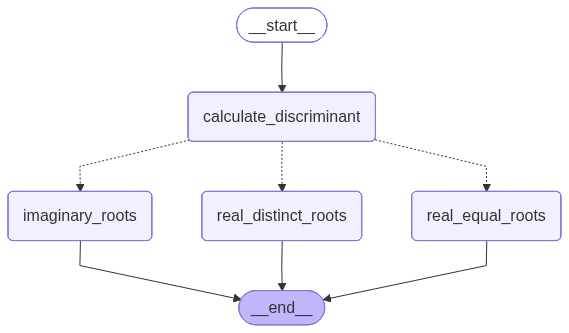

In [125]:
workflow

In [126]:
intial_state= {
    'a': 2,
    'b': 4,
    'c': 2
}

workflow.invoke(input = intial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'discriminant': 0,
 'root1': -1.0,
 'root2': -1.0,
 'result': 'the quadratic has 2 equal roots -1.0'}